Exploration de données Sujet 8

In [58]:
import pandas as pd

In [59]:
import matplotlib.pyplot as plt

In [60]:
df = pd.read_excel("Sujet8.xlsx")

In [61]:
df.head()

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
0,1,45,F,Asie,Free,Mobile,2,2.270508,33,5.977247,...,137,44,54,4,720,128.19,0.538574,2,7.627542,2.35747
1,2,32,H,Amérique,Free,DESktoP,1,31.196102,25,4.948077,...,121,43,54,15,0,110.86,0.894321,3,5.734792,78.368478
2,3,41,Autre,Afrique,Free,Mobile,1,38.464094,26,1.958113,...,87,23,30,14,165,107.6,0.740122,1,4.890083,88.838596
3,4,28,NaN,Europe,Free,Tablet,2,87.855813,36,5.015305,...,119,42,53,18,153,113.01,0.191904,3,6.314038,44.743723
4,5,30,H,Asie,Free,Tablet,2,32.797407,28,NaN,...,115,42,49,16,317,115.47,0.09866,5,7.3931,29.561283


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  4901 non-null   object
 1   age                      4882 non-null   object
 2   gender                   4877 non-null   object
 3   region                   4893 non-null   object
 4   subscription             4884 non-null   object
 5   device_type              4907 non-null   object
 6   nb_devices_used          4911 non-null   object
 7   time_on_platform         4900 non-null   object
 8   nb_sessions              4893 non-null   object
 9   avg_session_duration     4911 non-null   object
 10  premium_months           4889 non-null   object
 11  nb_friends               4911 non-null   object
 12  nb_groups                4897 non-null   object
 13  nb_pages_followed        4907 non-null   object
 14  nb_events_participated   4900 non-null  

In [63]:
df.isna()

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [64]:
df.isna().sum()

user_id                     99
age                        118
gender                     123
region                     107
subscription               116
device_type                 93
nb_devices_used             89
time_on_platform           100
nb_sessions                107
avg_session_duration        89
premium_months             111
nb_friends                  89
nb_groups                  103
nb_pages_followed           93
nb_events_participated     100
nb_searches                 89
nb_notifications_opened     98
nb_saved_posts             101
nb_reports                 101
nb_blocked_users            97
photos_posted               89
videos_posted              100
stories_posted              94
travels_shared              95
countries_visited           90
likes                       93
shares                     101
comments_written            73
reactions_given             89
reactions_received         115
messages_sent              102
messages_received           89
ads_clic

In [65]:
cols_cat = ["gender", "region", "subscription", "device_type"]

for col in cols_cat:
    df[col] = df[col].fillna("Unknown")

In [66]:
df["gender"].head(20)

0           F
1           H
2       Autre
3     Unknown
4           H
5       Autre
6           H
7       Autre
8           H
9           H
10      Autre
11      Autre
12          F
13          H
14      Autre
15          H
16          F
17      Autre
18    Autre??
19      Autre
Name: gender, dtype: object

In [67]:
df[cols_cat] = df[cols_cat].replace("Unknown", "Inconnu")

In [68]:
df["gender"].unique()

array(['F', 'H', 'Autre', 'Inconnu', 'Autre??', 'undefined', 'f', 'H??',
       'AUTRE', 'F??', 'h', 'H###', '???', 'autrE', 'AUTre', 'F###',
       'aUtRE', 'Autre###', 'AUtRe', 'AUTrE', 'AUtrE', 'AuTrE', 'aUTrE',
       'auTRe', 'aUTre', 'AuTRE', 'AuTRe', 'aUTRE'], dtype=object)

In [69]:
df["gender"] = df ["gender"].str.lower()

In [70]:
df["gender"] = df["gender"].str.replace(r'[?#]', '', regex=True)

In [71]:
to_replace = ['', 'undefined', '???']

In [72]:
df["gender"] = df["gender"].replace(to_replace, 'Inconnu')

In [73]:
mapping = {
    'h': 'H',
    'f': 'F',
    'autre': 'Autre',
    'inconnu': 'Inconnu'
}

In [74]:
df["gender"] = df["gender"].map(mapping).fillna('Inconnu')

In [75]:
df["gender"].unique()

array(['F', 'H', 'Autre', 'Inconnu'], dtype=object)

In [76]:
df["region"].unique()

array(['Asie', 'Amérique', 'Afrique', 'Europe', 'Amérique??', 'Inconnu',
       'Afrique###', 'amÉrique', 'undefined', '???', 'Asie??', 'AsIE',
       'aMÉrIque', 'AméRIQue', 'Asie###', 'Amérique###', 'AsIe',
       'AMÉrIqUe', 'aFriquE', 'AFRIquE', 'AMérique', 'afrIQue', 'asIe',
       'afrIque', 'ASIe', 'Europe??', 'eUrOpE', 'eURope', 'Europe###',
       'EUroPE', 'EURope', 'aSiE', 'aSie', 'asiE', 'AmÉrIQuE',
       'Afrique??', 'EUrOPE', 'euROpE', 'EuRope', 'AmÉriQUE', 'aFrIQUE',
       'aMériquE', 'AMÉrIQUE', 'eUropE', 'eurOpE', 'aFriQUE', 'AMériQUe',
       'AMéRiqUe', 'afRIque', 'AméRiQue', 'AFrIquE', 'eurOpe', 'AFrique',
       'euRoPe', 'ASIE', 'amérIQUe', 'eUrOPe', 'EurOpe', 'EuroPE',
       'aFriQue'], dtype=object)

In [77]:
df["subscription"].unique()

array(['Free', 'Premium', 'Inconnu', 'Free###', 'frEe', 'Free??', '???',
       'PREmiUm', 'Premium###', 'undefined', 'free', 'Premium??', 'fRee',
       'FrEE', 'FReE', 'premIuM', 'PrEMIum', 'FREE', 'pREMIUM', 'PrEMium',
       'FRee', 'PreMIUm', 'fREe', 'PremIuM', 'preMIUm', 'freE', 'FrEe',
       'FreE', 'PREMIUM', 'PrEmIUm', 'frEE', 'PReMIUM', 'pRemiUm',
       'prEmIuM', 'premiUm', 'PremIUm', 'fREE', 'prEmIum', 'fReE',
       'premIum', 'pREmIUm'], dtype=object)

In [78]:
df["device_type"].unique()

array(['Mobile', 'DESktoP', 'Tablet', 'Desktop', 'Tablet###', 'TaBLeT',
       'taBLEt', 'DeSKTop', 'mOBilE', 'Inconnu', '???', 'Desktop###',
       'Mobile??', 'Desktop??', 'Tablet??', 'dESKtOP', 'DESkTop',
       'undefined', 'Mobile###', 'deSktoP', 'MOBILe', 'deSkTop', 'MObIle',
       'DEskTOP', 'TAbLet', 'TABlET', 'desktOP', 'taBlET', 'MOBilE',
       'moBiLE', 'MOBiLe', 'tABLET', 'mobIlE', 'tabLET', 'DeSKTOp',
       'tablet', 'TAbLeT', 'tABlEt', 'MobilE', 'MoBiLE', 'MobiLe',
       'DESkTOP', 'deskTOp', 'TAblET', 'tAbLet', 'tABLeT', 'TAblet',
       'TabLet', 'dEsKToP', 'DeSKtOp', 'DeSKTOP', 'DESktOP', 'desKTop',
       'tABLet', 'DESKTOP', 'MoBIle', 'dESKToP', 'DeSKtOP', 'DeSKtop',
       'deSktop'], dtype=object)

In [79]:
cols_to_clean = ["region", "subscription", "device_type"]

for col in cols_to_clean:
    df[col] = df[col].astype(str).str.lower().str.replace(r'[?#]', '', regex=True).str.strip()
    df[col] = df[col].replace(['nan', 'undefined', '', 'none', '???'], 'inconnu')

region_map = {
    'europe': 'Europe',
    'asie': 'Asie',
    'amérique': 'Amérique',
    'afrique': "Afrique",
    'inconnu': 'Inconnu'
}

sub_map = {
    'free': 'Free',
    'premium': 'Premium',
    'inconnu': 'Inconnu'
}

device_map = {
    'mobile': 'Mobile',
    'desktop': 'Desktop',
    'tablet': 'Tablet'
}

df["region"] = df["region"].map(region_map).fillna('Inconnu')
df["subscription"] = df["subscription"].map(sub_map).fillna('Inconnu')
df["device_type"] = df["device_type"].map(device_map).fillna('Inconnu')
    

In [80]:
df["region"].unique()

array(['Asie', 'Amérique', 'Afrique', 'Europe', 'Inconnu'], dtype=object)

In [81]:
df["subscription"].unique()

array(['Free', 'Premium', 'Inconnu'], dtype=object)

In [82]:
df["device_type"].unique()

array(['Mobile', 'Desktop', 'Tablet', 'Inconnu'], dtype=object)

In [83]:
cols_num = df.select_dtypes(include=["float64", "int64"]).columns
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [84]:
df[cols_num].isna().sum()

Series([], dtype: float64)

In [85]:
df.dtypes

user_id                    object
age                        object
gender                     object
region                     object
subscription               object
device_type                object
nb_devices_used            object
time_on_platform           object
nb_sessions                object
avg_session_duration       object
premium_months             object
nb_friends                 object
nb_groups                  object
nb_pages_followed          object
nb_events_participated     object
nb_searches                object
nb_notifications_opened    object
nb_saved_posts             object
nb_reports                 object
nb_blocked_users           object
photos_posted              object
videos_posted              object
stories_posted             object
travels_shared             object
countries_visited          object
likes                      object
shares                     object
comments_written           object
reactions_given            object
reactions_rece

In [86]:
cols_num = [
    "age", "nb_devices_used", "time_on_platform", "nb_sessions",
    "avg_session_duration", "premium_months", "nb_friends",
    "nb_groups", "nb_pages_followed", "nb_events_participated",
    "nb_searches", "nb_notifications_opened", "nb_saved_posts",
    "nb_reports", "nb_blocked_users", "photos_posted",
    "videos_posted", "stories_posted", "travels_shared",
    "countries_visited", "likes", "shares", "comments_written",
    "reactions_given", "reactions_received", "messages_sent",
    "messages_received", "ads_clicked", "video_views",
    "engagement_score", "churn_risk", "satisfaction",
    "geo_lat", "geo_lon"
]

In [87]:
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [88]:
df[cols_num].dtypes

age                        float64
nb_devices_used            float64
time_on_platform           float64
nb_sessions                float64
avg_session_duration       float64
premium_months             float64
nb_friends                 float64
nb_groups                  float64
nb_pages_followed          float64
nb_events_participated     float64
nb_searches                float64
nb_notifications_opened    float64
nb_saved_posts             float64
nb_reports                 float64
nb_blocked_users           float64
photos_posted              float64
videos_posted              float64
stories_posted             float64
travels_shared             float64
countries_visited          float64
likes                      float64
shares                     float64
comments_written           float64
reactions_given            float64
reactions_received         float64
messages_sent              float64
messages_received          float64
ads_clicked                float64
video_views         

In [89]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [90]:
df[cols_num].isna().sum()

age                        0
nb_devices_used            0
time_on_platform           0
nb_sessions                0
avg_session_duration       0
premium_months             0
nb_friends                 0
nb_groups                  0
nb_pages_followed          0
nb_events_participated     0
nb_searches                0
nb_notifications_opened    0
nb_saved_posts             0
nb_reports                 0
nb_blocked_users           0
photos_posted              0
videos_posted              0
stories_posted             0
travels_shared             0
countries_visited          0
likes                      0
shares                     0
comments_written           0
reactions_given            0
reactions_received         0
messages_sent              0
messages_received          0
ads_clicked                0
video_views                0
engagement_score           0
churn_risk                 0
satisfaction               0
geo_lat                    0
geo_lon                    0
dtype: int64

In [91]:
df[cols_num].describe()

,age,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,premium_months,nb_friends,nb_groups,nb_pages_followed,nb_events_participated,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,41.945228,2.053454,62.762334,30.583851,5.104051,5.458797,153.771094,5.197686,20.625360,2.027887,...,121.029545,41.168419,50.840550,15.953694,385.966432,112.192986,0.500988,3.150795,40.871210,47.134289
std,25.778255,1.293660,77.705950,14.869988,3.056791,11.025287,81.635434,4.083932,13.439633,1.772026,...,47.957178,23.067126,25.111231,10.966539,352.836778,65.049915,0.410082,2.832665,30.949508,47.016020
min,-1.000000,-1.000000,-1.000000,-1.000000,-2.110610,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4.616363
25%,30.000000,1.000000,18.621420,26.000000,4.021963,0.000000,141.000000,3.000000,17.000000,1.000000,...,112.000000,36.000000,45.000000,12.000000,153.750000,99.027500,0.250628,2.000000,21.299288,16.544502
50%,41.945228,2.000000,45.303275,30.000000,5.053607,0.000000,150.000000,5.000000,20.000000,2.000000,...,120.000000,40.000000,50.000000,16.000000,339.000000,108.795000,0.500988,3.000000,40.806036,44.329272
75%,52.000000,3.000000,84.061755,33.000000,5.987652,5.458797,157.250000,6.000000,23.000000,3.000000,...,127.000000,44.000000,55.000000,19.000000,556.000000,117.615000,0.736996,4.000000,57.990530,73.816753
max,620.000000,30.000000,1980.845416,380.000000,83.135352,310.000000,1650.000000,110.000000,280.000000,60.000000,...,1380.000000,480.000000,630.000000,230.000000,9810.000000,1353.800000,9.611332,50.000000,750.682196,995.638623


In [92]:
df.loc[df["age"] < 0, "age"] = None
df.loc[df["age"] > 100, "age"] = None

In [93]:
df["age"] = df["age"].fillna(df["age"].mean())

In [94]:
df["age"].describe()

count    5000.000000
mean       40.937466
std        13.424788
min         0.000000
25%        30.000000
50%        41.945228
75%        52.000000
max        64.000000
Name: age, dtype: float64

In [95]:
df[[
    "time_on_platform",
    "avg_session_duration",
    "nb_sessions",
    "nb_friends",
    "engagement_score",
    "churn_risk",
    "satisfaction",
    "geo_lat",
    "geo_lon"
]].describe()

,time_on_platform,avg_session_duration,nb_sessions,nb_friends,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,62.762334,5.104051,30.583851,153.771094,112.192986,0.500988,3.150795,40.871210,47.134289
std,77.705950,3.056791,14.869988,81.635434,65.049915,0.410082,2.832665,30.949508,47.016020
min,-1.000000,-2.110610,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4.616363
25%,18.621420,4.021963,26.000000,141.000000,99.027500,0.250628,2.000000,21.299288,16.544502
50%,45.303275,5.053607,30.000000,150.000000,108.795000,0.500988,3.000000,40.806036,44.329272
75%,84.061755,5.987652,33.000000,157.250000,117.615000,0.736996,4.000000,57.990530,73.816753
max,1980.845416,83.135352,380.000000,1650.000000,1353.800000,9.611332,50.000000,750.682196,995.638623


In [96]:
cols_positive = [
    "time_on_platform", "avg_session_duration", "nb_sessions",
    "nb_friends", "engagement_score", "churn_risk", "satisfaction"
]

for col in cols_positive:
    df.loc[df[col] < 0, col] = None

In [97]:
df.loc[(df["geo_lat"] < -90) | (df["geo_lat"] > 90), "geo_lat"] = None
df.loc[(df["geo_lon"] < -180) | (df["geo_lon"] > 180), "geo_lon"] = None

In [98]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [99]:
df.loc[(df["churn_risk"] < 0) | (df["churn_risk"] > 1), "churn_risk"] = None

In [100]:
df.loc[(df["satisfaction"] < 1) | (df["satisfaction"] > 5), "satisfaction"] = None

In [101]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].mean())

In [102]:
df = df.replace("#", "", regex=True)

In [103]:
corr = df.corr(numeric_only=True)
print(corr)

                              age  nb_devices_used  time_on_platform  \
age                      1.000000         0.047563          0.003624   
nb_devices_used          0.047563         1.000000          0.012217   
time_on_platform         0.003624         0.012217          1.000000   
nb_sessions              0.016047         0.027770          0.000663   
avg_session_duration    -0.007424        -0.010204         -0.003496   
premium_months          -0.019946        -0.005738         -0.004989   
nb_friends               0.010004         0.025796         -0.002721   
nb_groups                0.001101        -0.016423          0.000074   
nb_pages_followed       -0.003954        -0.005016         -0.013032   
nb_events_participated   0.006315        -0.006511          0.005614   
nb_searches             -0.011868        -0.005904         -0.015767   
nb_notifications_opened  0.025735         0.005750          0.001115   
nb_saved_posts           0.021629        -0.009299          0.00

In [104]:
corr_matrix = df.corr(numeric_only=True)

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.5:
            print(row, "et", col, ":", corr_matrix.loc[row, col])

video_views et age : 0.6034114911387709
age et video_views : 0.6034114911387709


In [105]:
df["age"].describe()

count    5000.000000
mean       40.937466
std        13.424788
min         0.000000
25%        30.000000
50%        41.945228
75%        52.000000
max        64.000000
Name: age, dtype: float64

In [106]:
df["video_views"].describe()

count    5000.000000
mean      385.966432
std       352.836778
min        -1.000000
25%       153.750000
50%       339.000000
75%       556.000000
max      9810.000000
Name: video_views, dtype: float64

In [107]:
df.loc[df["video_views"] < 0]

,user_id,age,gender,region,subscription,device_type,nb_devices_used,time_on_platform,nb_sessions,avg_session_duration,...,reactions_received,messages_sent,messages_received,ads_clicked,video_views,engagement_score,churn_risk,satisfaction,geo_lat,geo_lon
176,NaN,39.0,F,Amérique,Inconnu,Mobile,3.0,121.563286,30.697964,4.079449,...,119.0,46.0,48.0,20.0,-1.0,104.610000,0.093543,3.000000,5.498793,64.590014
627,628,23.0,H,Afrique,Free,Mobile,3.0,5.564662,29.000000,5.687590,...,118.0,40.0,47.0,7.0,-1.0,116.360000,0.660695,4.000000,10.623628,0.000000
1462,1463,55.0,H,Europe,Free,Desktop,2.0,0.260145,31.000000,4.058302,...,121.0,31.0,39.0,0.0,-1.0,125.550000,0.910517,4.000000,21.280402,77.238538
1499,1500,50.0,F,Amérique,Free,Tablet,2.0,238.867853,32.000000,3.930022,...,118.0,41.0,52.0,23.0,-1.0,97.270000,0.424607,4.000000,20.541862,63.979374
1872,1873,22.0,H,Amérique,Free,Mobile,2.0,18.018470,29.000000,4.934863,...,124.0,40.0,45.0,12.0,-1.0,93.310000,0.841426,4.000000,27.459262,17.622067
1982,1983,48.0,Autre,Amérique,Inconnu,Desktop,3.0,29.144184,29.000000,5.719308,...,115.0,41.0,51.0,17.0,-1.0,112.192986,0.508397,1.000000,29.625891,47.348002
2290,2291,52.0,Autre,Amérique,Free,Desktop,1.0,142.677458,34.000000,3.934674,...,134.0,43.0,48.0,21.0,-1.0,109.440000,0.299885,4.000000,36.335292,95.422367
2373,2374,52.0,H,Amérique,Free,Mobile,1.0,1.219934,42.000000,3.903176,...,136.0,46.0,57.0,3.0,-1.0,125.430000,0.812786,4.000000,41.214682,39.998552
3253,3254,34.0,F,Afrique,Free,Tablet,2.0,19.957877,42.000000,4.611902,...,128.0,41.0,51.0,13.0,-1.0,118.530000,0.615855,3.000000,50.758630,49.467554
4415,4416,64.0,Autre,Amérique,Free,Mobile,2.0,71.852973,27.000000,5.174054,...,127.0,38.0,47.0,17.0,-1.0,116.230000,0.206589,3.150795,72.290901,17.292318


In [108]:
df.loc[df["video_views"] < 0, "video_views"] = None

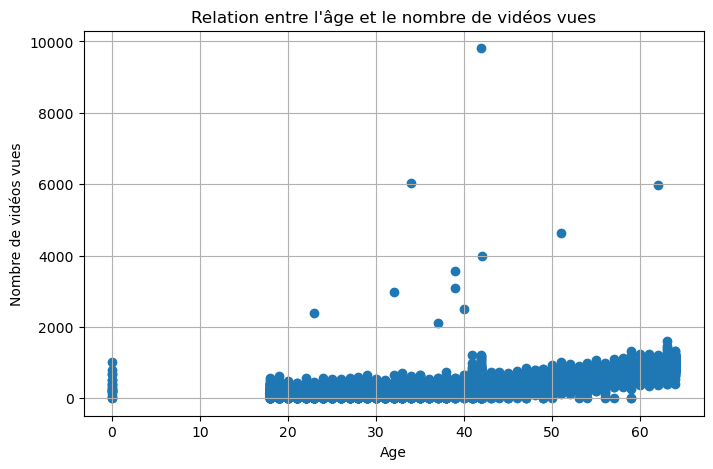

In [109]:
plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["video_views"])

plt.xlabel("Age")
plt.ylabel("Nombre de vidéos vues")
plt.title("Relation entre l'âge et le nombre de vidéos vues")

plt.grid(True)

plt.show()

In [110]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_19388\437661633.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("age_bin")["video_views"].mean()


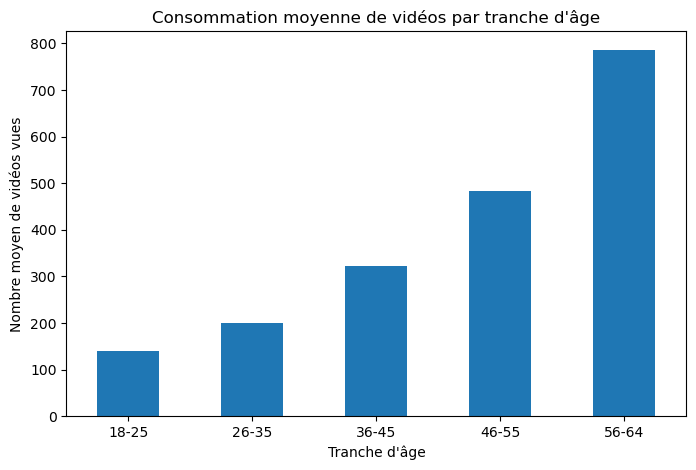

In [111]:
grp = df.groupby("age_bin")["video_views"].mean()

plt.figure(figsize=(8,5))

grp.plot(kind="bar")

plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre moyen de vidéos vues")
plt.title("Consommation moyenne de vidéos par tranche d'âge")

plt.xticks(rotation=0)

plt.show()

In [112]:
df.loc[df["likes"] < 0, "likes"] = None

In [113]:
cols = [
    "video_views",
    "nb_sessions",
    "likes",
    "time_on_platform",
    "nb_friends",
    "engagement_score",
    "churn_risk"
]

correlations = []

for col in cols:
    r = df["age"].corr(df[col])
    correlations.append(r)

corr_series = pd.Series(correlations, index=cols)

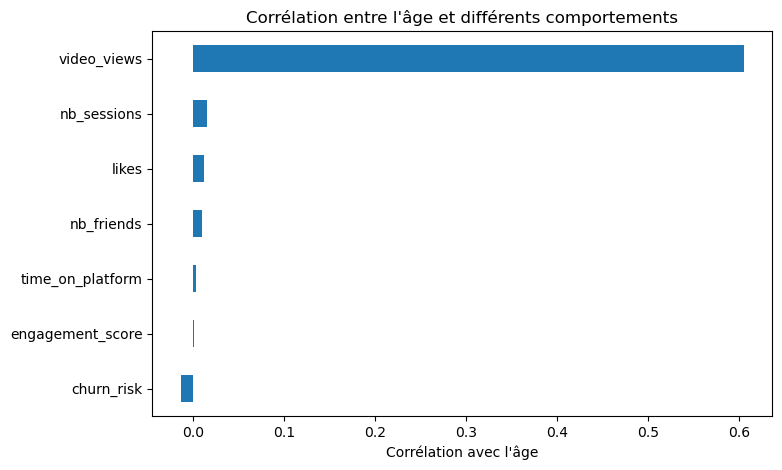

In [114]:

plt.figure(figsize=(8,5))

corr_series.sort_values().plot(kind="barh")

plt.xlabel("Corrélation avec l'âge")
plt.title("Corrélation entre l'âge et différents comportements")

plt.show()